This notebook explores the use of Euclidean and Hyperbolic Variational Autoencoders (VAEs) for image data. It also includes the training of classifiers on the latent spaces learned by these VAEs.

In [1]:
!pip install -q geoopt torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 2.9 MB/s eta 0:00:00


In [2]:
import os # importing librariers needed for this study
import math
import warnings

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import geoopt
from geoopt import PoincareBall
from geoopt.optim import RiemannianAdam

warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Masters/Project/data')

Mounted at /content/drive


In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

In [7]:
DATA_DIR = "Histopathological Image"
IMG_SIZE = 128

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Found {len(full_dataset)} images across {num_classes} classes: {class_names}")

indices = list(range(len(full_dataset)))
labels = [label for _, label in full_dataset.samples]

# 70/15/15 data splits
train_idx, rest_idx = train_test_split(
    indices, test_size=0.3, random_state=SEED, stratify=labels
)
rest_labels = [labels[i] for i in rest_idx]
val_idx, test_idx = train_test_split(
    rest_idx, test_size=0.5, random_state=SEED, stratify=rest_labels
)

train_ds = Subset(full_dataset, train_idx)
val_ds = Subset(full_dataset, val_idx)
test_ds = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

IN_CHANNELS = 1

Found 3302 images across 7 classes: ['EA', 'EH - Complex', 'EH - Simple', 'EP', 'NE - Follicular', 'NE - Luteal', 'NE - Menstrual']


# **Histo Encoder*

In [14]:
class ConvEncoder(nn.Module):
    """Image -> (mu, logvar) over the latent space."""

    def __init__(self, in_channels=1, latent_dim=50, img_size=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
        )
        self.reduced_size = img_size // 8
        flat_dim = 128 * self.reduced_size * self.reduced_size
        self.fc_mu = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x)
        h = h.flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

# **Histo Decoder**

In [ ]:
class ConvDecoder(nn.Module):
    """Latent vector -> reconstructed image."""

    def __init__(self, latent_dim=50, out_channels=1, img_size=128):
        super().__init__()
        self.reduced_size = img_size // 8
        flat_dim = 128 * self.reduced_size * self.reduced_size
        self.fc = nn.Linear(latent_dim, flat_dim)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, out_channels, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z)
        h = h.view(-1, 128, self.reduced_size, self.reduced_size)
        return self.deconv(h)

# **Histo Loss**

In [ ]:
def vae_loss(recon, x, mu, logvar):
    recon_loss = F.mse_loss(recon, x, reduction="sum") / x.size(0)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + kld, recon_loss, kld

# **Histo Euclidean**

In [15]:
BATCH_SIZE = 64
LATENT_DIM = 50
EPOCHS = 100
CLF_EPOCHS = 50
CURVATURE = 1.0
LEARNING_RATE = 0.001

class EuclideanVAE(nn.Module):
    def __init__(self, in_channels=1, latent_dim=50, img_size=128):
        super().__init__()
        self.encoder = ConvEncoder(in_channels, latent_dim, img_size)
        self.decoder = ConvDecoder(latent_dim, in_channels, img_size)

    def reparameterize(self, mu, logvar): #clamping to prevent massive spikes
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar


def train_euclidean_vae(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE,
                         grad_clip=5.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "val_recon": [], "val_kld": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for x, _ in train_loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()
            recon, mu, logvar = model(x)
            loss, _, _ = vae_loss(recon, x, mu, logvar)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            train_loss += loss.item() * x.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_recon = 0.0
        val_kld = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(DEVICE)
                recon, mu, logvar = model(x)
                loss, recon_loss, kld = vae_loss(recon, x, mu, logvar)
                val_loss += loss.item() * x.size(0)
                val_recon += recon_loss.item() * x.size(0)
                val_kld += kld.item() * x.size(0)
        val_loss /= len(val_loader.dataset)
        val_recon /= len(val_loader.dataset)
        val_kld /= len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_recon"].append(val_recon)
        history["val_kld"].append(val_kld)
        print(f"[Euclidean VAE] Epoch {epoch + 1}/{epochs}  train={train_loss:.4f}  "
              f"val={val_loss:.4f}  (recon={val_recon:.4f}, kld={val_kld:.4f})")

    return history

# **Histo Hyperbolic**

In [16]:
class HyperbolicVAE(nn.Module):
    def __init__(self, in_channels=1, latent_dim=50, img_size=128, curvature=1.0):
        super().__init__()
        self.encoder = ConvEncoder(in_channels, latent_dim, img_size)
        self.decoder = ConvDecoder(latent_dim, in_channels, img_size)
        self.ball = PoincareBall(c=curvature)

    def reparameterize(self, mu, logvar):
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z_euclidean = self.reparameterize(mu, logvar)

        z_hyperbolic = self.ball.expmap0(z_euclidean)
        z_tangent = self.ball.logmap0(z_hyperbolic)

        recon = self.decoder(z_tangent)
        return recon, mu, logvar, z_hyperbolic


def train_hyperbolic_vae(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE,
                          grad_clip=5.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "val_recon": [], "val_kld": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for x, _ in train_loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()
            recon, mu, logvar, _ = model(x)
            loss, _, _ = vae_loss(recon, x, mu, logvar)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            train_loss += loss.item() * x.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_recon = 0.0
        val_kld = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(DEVICE)
                recon, mu, logvar, _ = model(x)
                loss, recon_loss, kld = vae_loss(recon, x, mu, logvar)
                val_loss += loss.item() * x.size(0)
                val_recon += recon_loss.item() * x.size(0)
                val_kld += kld.item() * x.size(0)
        val_loss /= len(val_loader.dataset)
        val_recon /= len(val_loader.dataset)
        val_kld /= len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_recon"].append(val_recon)
        history["val_kld"].append(val_kld)
        print(f"[Hyperbolic VAE] Epoch {epoch + 1}/{epochs}  train={train_loss:.4f}  "
              f"val={val_loss:.4f}  (recon={val_recon:.4f}, kld={val_kld:.4f})")

    return history

# **Downstream classifiers**

In [17]:
class LatentCNNClassifier(nn.Module):
    def __init__(self, latent_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(64, num_classes)

    def forward(self, z):
        z = z.unsqueeze(1)
        features = self.net(z).squeeze(-1)
        return self.fc(features)


class HyperbolicPrototypeClassifier(nn.Module):
    def __init__(self, latent_dim, num_classes, curvature=1.0):
        super().__init__()
        self.ball = PoincareBall(c=curvature)
        init = self.ball.expmap0(0.01 * torch.randn(num_classes, latent_dim))
        self.prototypes = geoopt.ManifoldParameter(init, manifold=self.ball)
        self.scale = nn.Parameter(torch.tensor(5.0))

    def forward(self, z_hyperbolic):
        batch = z_hyperbolic.size(0)
        n_classes = self.prototypes.size(0)
        z_tiled = z_hyperbolic.unsqueeze(1).expand(batch, n_classes, -1)
        p_tiled = self.prototypes.unsqueeze(0).expand(batch, n_classes, -1)
        dists = self.ball.dist(z_tiled, p_tiled)
        return -dists * self.scale

def train_classifier(model, encoder_fn, loader, val_loader, num_epochs=CLF_EPOCHS,
                      lr=LEARNING_RATE, manifold_params=False):
    """encoder_fn(x) -> latent tensor fed to the classifier. VAE stays frozen."""
    optimizer = RiemannianAdam(model.parameters(), lr=lr) if manifold_params \
        else torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            with torch.no_grad():
                z = encoder_fn(x)
            optimizer.zero_grad()
            logits = model(z)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
        total_loss /= len(loader.dataset)

        model.eval()
        correct = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                z = encoder_fn(x)
                preds = model(z).argmax(dim=1)
                correct += (preds == y).sum().item()
        val_acc = correct / len(val_loader.dataset)

        history["train_loss"].append(total_loss)
        history["val_acc"].append(val_acc)
        print(f"  Epoch {epoch + 1}/{num_epochs}  loss={total_loss:.4f}  val_acc={val_acc:.4f}")

    return history


@torch.no_grad()
def evaluate_classifier(model, encoder_fn, loader, num_classes): # setting out the metrics that will be used to evaluate the models performance

    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        z = encoder_fn(x)
        logits = model(z)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        all_labels.append(y.cpu())
        all_preds.append(preds.cpu())
        all_probs.append(probs.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()
    all_probs = torch.cat(all_probs).numpy()

    accuracy = float((all_preds == all_labels).mean())

    try:
        if num_classes == 2:
            auc = roc_auc_score(all_labels, all_probs[:, 1])
        else:
            auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
    except ValueError as e:
        auc = float("nan")
        print(f"  (AUC could not be computed: {e})")

    spearman_corr, spearman_p = spearmanr(all_labels, all_preds)

    return {
        "accuracy": accuracy,
        "auc": auc,
        "spearman_corr": float(spearman_corr),
        "spearman_p": float(spearman_p),
    }

# **Histo Euclidean Testing**

In [18]:
euc_vae = EuclideanVAE(IN_CHANNELS, LATENT_DIM, IMG_SIZE).to(DEVICE)
euc_history = train_euclidean_vae(euc_vae, train_loader, val_loader, epochs=EPOCHS)

[Euclidean VAE] Epoch 1/100  train=13091275.9410  val=20282.6238  (recon=651.1205, kld=19631.5035)
[Euclidean VAE] Epoch 2/100  train=1619402.6128  val=78927.3214  (recon=1427.2626, kld=77500.0563)
[Euclidean VAE] Epoch 3/100  train=9222.7198  val=27827.1909  (recon=289.6110, kld=27537.5801)
[Euclidean VAE] Epoch 4/100  train=208380599.2912  val=817808.6171  (recon=255.9379, kld=817552.6776)
[Euclidean VAE] Epoch 5/100  train=1297.6630  val=561.6188  (recon=258.1131, kld=303.5057)
[Euclidean VAE] Epoch 6/100  train=458.0175  val=375.9150  (recon=241.2664, kld=134.6485)
[Euclidean VAE] Epoch 7/100  train=341.0722  val=2179.3779  (recon=244.8850, kld=1934.4929)
[Euclidean VAE] Epoch 8/100  train=9056.8052  val=464.3332  (recon=231.4573, kld=232.8759)
[Euclidean VAE] Epoch 9/100  train=369.9716  val=638.4197  (recon=226.1300, kld=412.2897)
[Euclidean VAE] Epoch 10/100  train=352.6677  val=722.3109  (recon=261.9443, kld=460.3666)
[Euclidean VAE] Epoch 11/100  train=9876.7407  val=319.4471 

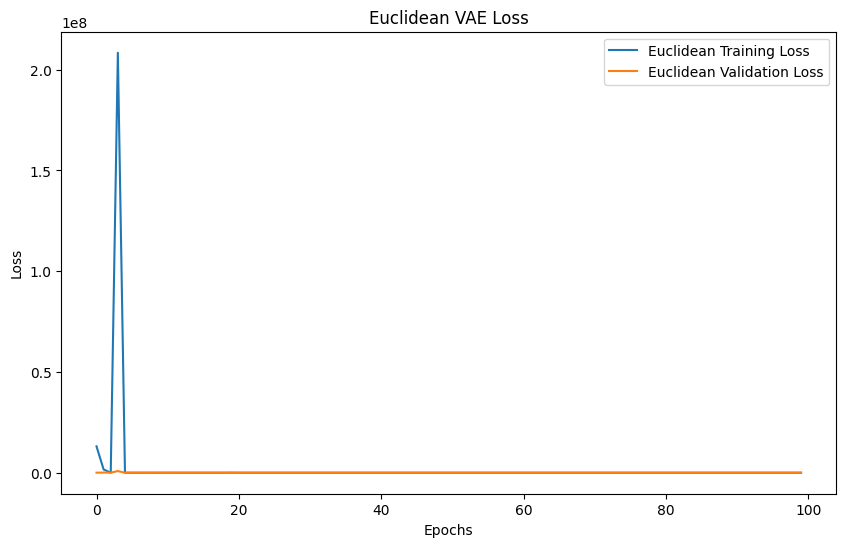

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(euc_history["train_loss"], label="Euclidean Training Loss")
plt.plot(euc_history["val_loss"], label="Euclidean Validation Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()
plt.title("Euclidean VAE Loss")
plt.show()

In [1]:
plt.figure(figsize=(10, 6))
plt.plot(euc_history["val_recon"], label="Val Reconstruction Loss")
plt.plot(euc_history["val_kld"], label="Val KL Divergence")
plt.xlabel("Epochs"); plt.ylabel("Loss component"); plt.legend()
plt.title("Euclidean VAE — Reconstruction vs. KL")
plt.show()

NameError: name 'plt' is not defined

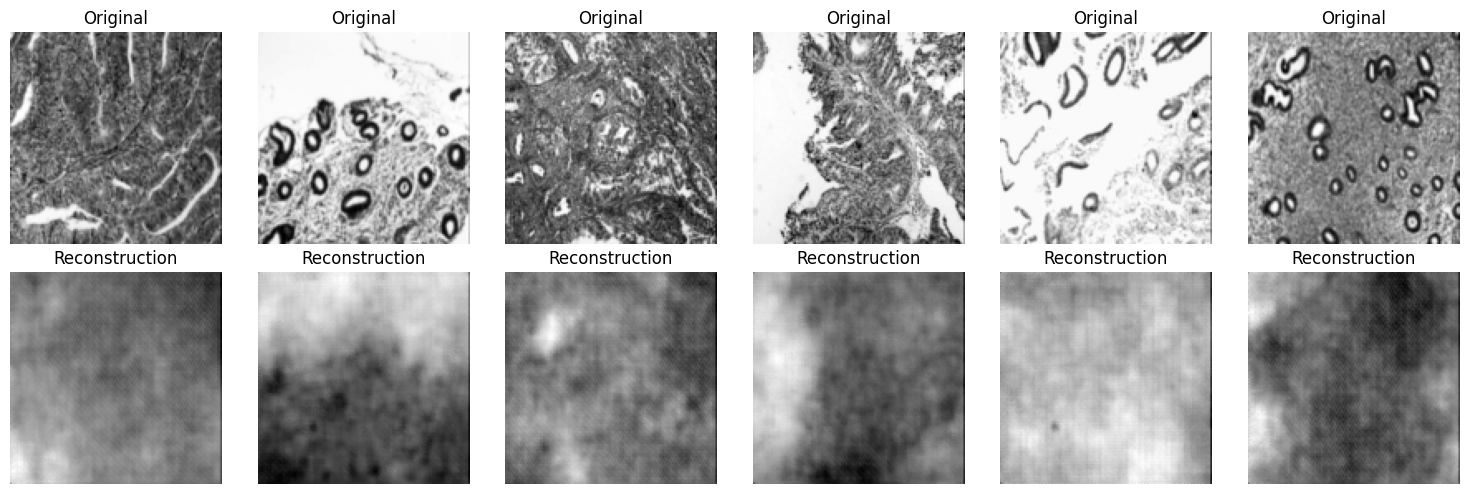

In [21]:
euc_vae.eval() # checking to see if the images share any resembelnce
with torch.no_grad():
    sample_x, _ = next(iter(val_loader))
    sample_x = sample_x[:6].to(DEVICE)
    recon, _, _ = euc_vae(sample_x)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(6):
    axes[0, i].imshow(sample_x[i, 0].cpu(), cmap="gray")
    axes[0, i].set_title("Original"); axes[0, i].axis("off")
    axes[1, i].imshow(recon[i, 0].cpu(), cmap="gray")
    axes[1, i].set_title("Reconstruction"); axes[1, i].axis("off")
plt.tight_layout()
plt.show()

# **Histo Hyperbolic Training**

In [22]:
hyp_vae = HyperbolicVAE(IN_CHANNELS, LATENT_DIM, IMG_SIZE, curvature=CURVATURE).to(DEVICE)
hyp_history = train_hyperbolic_vae(hyp_vae, train_loader, val_loader, epochs=EPOCHS)

[Hyperbolic VAE] Epoch 1/100  train=12685.0805  val=909.1783  (recon=321.7979, kld=587.3804)
[Hyperbolic VAE] Epoch 2/100  train=6777.0875  val=3006484999.4009  (recon=379.6085, kld=3006484666.5088)
[Hyperbolic VAE] Epoch 3/100  train=923.6271  val=1057.4481  (recon=268.9410, kld=788.5072)
[Hyperbolic VAE] Epoch 4/100  train=683.3346  val=475.3383  (recon=243.2394, kld=232.0989)
[Hyperbolic VAE] Epoch 5/100  train=1027.8227  val=45167.5281  (recon=294.8799, kld=44872.6475)
[Hyperbolic VAE] Epoch 6/100  train=318.1983  val=414.6615  (recon=340.5168, kld=74.1446)
[Hyperbolic VAE] Epoch 7/100  train=226.8503  val=285.9513  (recon=251.0191, kld=34.9323)
[Hyperbolic VAE] Epoch 8/100  train=221.3266  val=367.2472  (recon=341.8333, kld=25.4139)
[Hyperbolic VAE] Epoch 9/100  train=211.5895  val=207.7764  (recon=188.1058, kld=19.6705)
[Hyperbolic VAE] Epoch 10/100  train=204.6409  val=238.4839  (recon=215.7214, kld=22.7625)
[Hyperbolic VAE] Epoch 11/100  train=205.8785  val=205.3178  (recon=184

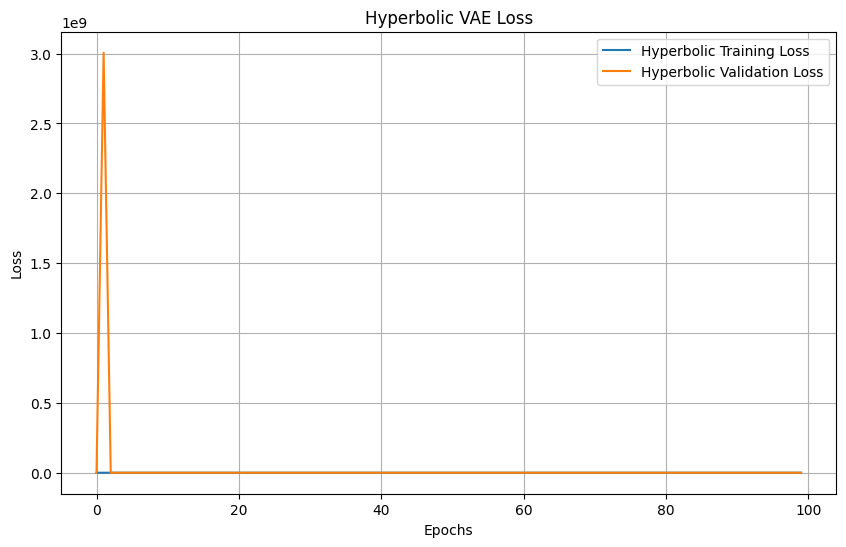

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(hyp_history["train_loss"], label="Hyperbolic Training Loss")
plt.plot(hyp_history["val_loss"], label="Hyperbolic Validation Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
plt.title("Hyperbolic VAE Loss")
plt.show()

# **Histo Evaluation**

In [24]:
euc_vae.eval()
hyp_vae.eval()

def euc_encoder_fn(x):
    mu, _ = euc_vae.encoder(x)
    return mu

def hyp_encoder_fn(x):
    mu, _ = hyp_vae.encoder(x)
    return hyp_vae.ball.expmap0(mu)

In [25]:
print("Training Euclidean-latent CNN classifier...")
euc_clf = LatentCNNClassifier(LATENT_DIM, num_classes).to(DEVICE)
train_classifier(euc_clf, euc_encoder_fn, train_loader, val_loader)
euc_metrics = evaluate_classifier(euc_clf, euc_encoder_fn, test_loader, num_classes)
print(f"Euclidean-latent classifier — accuracy: {euc_metrics['accuracy']:.4f}, "
      f"AUC: {euc_metrics['auc']:.4f}, "
      f"Spearman's rho: {euc_metrics['spearman_corr']:.4f} (p={euc_metrics['spearman_p']:.4f})")

Training Euclidean-latent CNN classifier...
  Epoch 1/50  loss=1.8611  val_acc=0.2848
  Epoch 2/50  loss=1.7528  val_acc=0.2990
  Epoch 3/50  loss=1.7304  val_acc=0.3030
  Epoch 4/50  loss=1.7212  val_acc=0.2970
  Epoch 5/50  loss=1.7132  val_acc=0.3111
  Epoch 6/50  loss=1.7117  val_acc=0.3111
  Epoch 7/50  loss=1.7066  val_acc=0.3030
  Epoch 8/50  loss=1.7061  val_acc=0.2909
  Epoch 9/50  loss=1.7042  val_acc=0.3051
  Epoch 10/50  loss=1.7028  val_acc=0.3051
  Epoch 11/50  loss=1.7006  val_acc=0.3131
  Epoch 12/50  loss=1.7003  val_acc=0.3111
  Epoch 13/50  loss=1.6978  val_acc=0.3051
  Epoch 14/50  loss=1.6953  val_acc=0.3030
  Epoch 15/50  loss=1.6970  val_acc=0.3212
  Epoch 16/50  loss=1.6930  val_acc=0.3010
  Epoch 17/50  loss=1.6903  val_acc=0.3394
  Epoch 18/50  loss=1.6919  val_acc=0.3111
  Epoch 19/50  loss=1.6859  val_acc=0.2929
  Epoch 20/50  loss=1.6860  val_acc=0.2707
  Epoch 21/50  loss=1.6849  val_acc=0.3051
  Epoch 22/50  loss=1.6859  val_acc=0.2889
  Epoch 23/50  loss

In [26]:
print("Training Hyperbolic prototype classifier...")
hyp_clf = HyperbolicPrototypeClassifier(LATENT_DIM, num_classes, curvature=CURVATURE).to(DEVICE)
train_classifier(hyp_clf, hyp_encoder_fn, train_loader, val_loader, manifold_params=True)
hyp_metrics = evaluate_classifier(hyp_clf, hyp_encoder_fn, test_loader, num_classes)
print(f"Hyperbolic-latent classifier — accuracy: {hyp_metrics['accuracy']:.4f}, "
      f"AUC: {hyp_metrics['auc']:.4f}, "
      f"Spearman's rho: {hyp_metrics['spearman_corr']:.4f} (p={hyp_metrics['spearman_p']:.4f})")

Training Hyperbolic prototype classifier...
  Epoch 1/50  loss=1.9414  val_acc=0.1879
  Epoch 2/50  loss=1.9207  val_acc=0.2121
  Epoch 3/50  loss=1.9017  val_acc=0.2242
  Epoch 4/50  loss=1.8836  val_acc=0.2485
  Epoch 5/50  loss=1.8663  val_acc=0.2566
  Epoch 6/50  loss=1.8498  val_acc=0.2626
  Epoch 7/50  loss=1.8340  val_acc=0.2606
  Epoch 8/50  loss=1.8192  val_acc=0.2667
  Epoch 9/50  loss=1.8053  val_acc=0.2626
  Epoch 10/50  loss=1.7924  val_acc=0.2646
  Epoch 11/50  loss=1.7804  val_acc=0.2667
  Epoch 12/50  loss=1.7693  val_acc=0.2646
  Epoch 13/50  loss=1.7592  val_acc=0.2687
  Epoch 14/50  loss=1.7499  val_acc=0.2626
  Epoch 15/50  loss=1.7413  val_acc=0.2707
  Epoch 16/50  loss=1.7336  val_acc=0.2808
  Epoch 17/50  loss=1.7263  val_acc=0.2869
  Epoch 18/50  loss=1.7197  val_acc=0.2970
  Epoch 19/50  loss=1.7135  val_acc=0.2949
  Epoch 20/50  loss=1.7078  val_acc=0.2990
  Epoch 21/50  loss=1.7024  val_acc=0.3030
  Epoch 22/50  loss=1.6974  val_acc=0.3071
  Epoch 23/50  loss

In [27]:
print(f"Summary:\n"
      f"  Euclidean latent space  — accuracy: {euc_metrics['accuracy']:.4f}, "
      f"AUC: {euc_metrics['auc']:.4f}, Spearman's rho: {euc_metrics['spearman_corr']:.4f}\n"
      f"  Hyperbolic latent space — accuracy: {hyp_metrics['accuracy']:.4f}, "
      f"AUC: {hyp_metrics['auc']:.4f}, Spearman's rho: {hyp_metrics['spearman_corr']:.4f}")

Summary:
  Euclidean latent space  — accuracy: 0.2984, AUC: 0.6393, Spearman's rho: 0.1448
  Hyperbolic latent space — accuracy: 0.3044, AUC: 0.6654, Spearman's rho: 0.1117


# **GLENDA Dataset**

From here the same procedures will take place on the GLENDA Dataset to cross validate the results

In [5]:
Glenda = "Surgery Images/frames"

In [ ]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1), # changes the image to grayscale
    transforms.ToTensor(),
])


In [9]:
Glenda_Dataset = datasets.ImageFolder(root=Glenda, transform=transforms)
class_names = Glenda_Dataset.classes
num_classes = len(class_names)
class_names

['Ovary', 'Peritoneum', 'Uterus', 'die']

In [11]:
full_dataset = datasets.ImageFolder(root=Glenda, transform=transform)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Found {len(full_dataset)} images across {num_classes} classes: {class_names}")

indices = list(range(len(full_dataset)))
labels = [label for _, label in full_dataset.samples]

# split the data into 70/15/15
train_idx, rest_idx = train_test_split(
    indices, test_size=0.3, random_state=SEED, stratify=labels
)
rest_labels = [labels[i] for i in rest_idx]
val_idx, test_idx = train_test_split(
    rest_idx, test_size=0.5, random_state=SEED, stratify=rest_labels
)

train_ds = Subset(full_dataset, train_idx)
val_ds = Subset(full_dataset, val_idx)
test_ds = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False) # load in the different data splits

IN_CHANNELS = 1

Found 373 images across 4 classes: ['Ovary', 'Peritoneum', 'Uterus', 'die']


# **GLENDA Encoder**

In [ ]:
class ConvEncoder(nn.Module):
    """Image -> (mu, logvar) over the latent space."""

    def __init__(self, in_channels=1, latent_dim=50, img_size=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 4, stride=2, padding=1),   # /2
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),            # /4
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),           # /8
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
        )
        self.reduced_size = img_size // 8
        flat_dim = 128 * self.reduced_size * self.reduced_size
        self.fc_mu = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x)
        h = h.flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)


# **GLENDA Decoder**

In [12]:
class ConvDecoder(nn.Module):
    """Latent vector -> reconstructed image."""

    def __init__(self, latent_dim=50, out_channels=1, img_size=128):
        super().__init__()
        self.reduced_size = img_size // 8
        flat_dim = 128 * self.reduced_size * self.reduced_size
        self.fc = nn.Linear(latent_dim, flat_dim)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, out_channels, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z)
        h = h.view(-1, 128, self.reduced_size, self.reduced_size)
        return self.deconv(h)

# **GLENDA Loss**

In [ ]:
def vae_loss(recon, x, mu, logvar):
    recon_loss = F.mse_loss(recon, x, reduction="sum") / x.size(0)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + kld, recon_loss, kld

# **GLENDA Euclidean**

In [13]:
class EuclideanVAE(nn.Module):
    def __init__(self, in_channels=1, latent_dim=50, img_size=128):
        super().__init__()
        self.encoder = ConvEncoder(in_channels, latent_dim, img_size)
        self.decoder = ConvDecoder(latent_dim, in_channels, img_size)

    def reparameterize(self, mu, logvar):
        logvar = torch.clamp(logvar, min=-10.0, max=10.0) #clamp to prevent massive spikes
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar


def train_euclidean_vae(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE,
                         grad_clip=5.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "val_recon": [], "val_kld": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for x, _ in train_loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()
            recon, mu, logvar = model(x)
            loss, _, _ = vae_loss(recon, x, mu, logvar)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            train_loss += loss.item() * x.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_recon = 0.0
        val_kld = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(DEVICE)
                recon, mu, logvar = model(x)
                loss, recon_loss, kld = vae_loss(recon, x, mu, logvar)
                val_loss += loss.item() * x.size(0)
                val_recon += recon_loss.item() * x.size(0)
                val_kld += kld.item() * x.size(0)
        val_loss /= len(val_loader.dataset)
        val_recon /= len(val_loader.dataset)
        val_kld /= len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_recon"].append(val_recon)
        history["val_kld"].append(val_kld)
        print(f"[Euclidean VAE] Epoch {epoch + 1}/{epochs}  train={train_loss:.4f}  "
              f"val={val_loss:.4f}  (recon={val_recon:.4f}, kld={val_kld:.4f})")

    return history

# **GLENDA Hyperbolic**

In [14]:
class HyperbolicVAE(nn.Module):
    def __init__(self, in_channels=1, latent_dim=50, img_size=128, curvature=1.0):
        super().__init__()
        self.encoder = ConvEncoder(in_channels, latent_dim, img_size)
        self.decoder = ConvDecoder(latent_dim, in_channels, img_size)
        self.ball = PoincareBall(c=curvature)

    def reparameterize(self, mu, logvar):
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std # clamps the gradient to prevent massive spikes

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z_euclidean = self.reparameterize(mu, logvar)

        z_hyperbolic = self.ball.expmap0(z_euclidean)
        z_tangent = self.ball.logmap0(z_hyperbolic)

        recon = self.decoder(z_tangent)
        return recon, mu, logvar, z_hyperbolic


def train_hyperbolic_vae(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE,
                          grad_clip=5.0):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "val_recon": [], "val_kld": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for x, _ in train_loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()
            recon, mu, logvar, _ = model(x)
            loss, _, _ = vae_loss(recon, x, mu, logvar)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            train_loss += loss.item() * x.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_recon = 0.0
        val_kld = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(DEVICE)
                recon, mu, logvar, _ = model(x)
                loss, recon_loss, kld = vae_loss(recon, x, mu, logvar)
                val_loss += loss.item() * x.size(0)
                val_recon += recon_loss.item() * x.size(0)
                val_kld += kld.item() * x.size(0)
        val_loss /= len(val_loader.dataset)
        val_recon /= len(val_loader.dataset)
        val_kld /= len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_recon"].append(val_recon)
        history["val_kld"].append(val_kld)
        print(f"[Hyperbolic VAE] Epoch {epoch + 1}/{epochs}  train={train_loss:.4f}  "
              f"val={val_loss:.4f}  (recon={val_recon:.4f}, kld={val_kld:.4f})")

    return history

# **Downstream Classifiers**

In [15]:
class LatentCNNClassifier(nn.Module):
    def __init__(self, latent_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(64, num_classes)

    def forward(self, z):
        z = z.unsqueeze(1)
        features = self.net(z).squeeze(-1)
        return self.fc(features)


class HyperbolicPrototypeClassifier(nn.Module):
    def __init__(self, latent_dim, num_classes, curvature=1.0):
        super().__init__()
        self.ball = PoincareBall(c=curvature) # set out poincare ball for different latent geometry
        init = self.ball.expmap0(0.01 * torch.randn(num_classes, latent_dim))
        self.prototypes = geoopt.ManifoldParameter(init, manifold=self.ball)
        self.scale = nn.Parameter(torch.tensor(5.0))

    def forward(self, z_hyperbolic):
        batch = z_hyperbolic.size(0)
        n_classes = self.prototypes.size(0)
        z_tiled = z_hyperbolic.unsqueeze(1).expand(batch, n_classes, -1)
        p_tiled = self.prototypes.unsqueeze(0).expand(batch, n_classes, -1)
        dists = self.ball.dist(z_tiled, p_tiled)
        return -dists * self.scale


def train_classifier(model, encoder_fn, loader, val_loader, num_epochs=CLF_EPOCHS,
                      lr=LEARNING_RATE, manifold_params=False):
    """encoder_fn(x) -> latent tensor fed to the classifier. VAE stays frozen."""
    optimizer = RiemannianAdam(model.parameters(), lr=lr) if manifold_params \
        else torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            with torch.no_grad():
                z = encoder_fn(x)
            optimizer.zero_grad()
            logits = model(z)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
        total_loss /= len(loader.dataset)

        model.eval()
        correct = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                z = encoder_fn(x)
                preds = model(z).argmax(dim=1)
                correct += (preds == y).sum().item()
        val_acc = correct / len(val_loader.dataset)

        history["train_loss"].append(total_loss)
        history["val_acc"].append(val_acc)
        print(f"  Epoch {epoch + 1}/{num_epochs}  loss={total_loss:.4f}  val_acc={val_acc:.4f}")

    return history


@torch.no_grad()
def evaluate_classifier(model, encoder_fn, loader, num_classes):
    """Returns accuracy, ROC-AUC, and Spearman's rank correlation.

    AUC: one-vs-rest, macro-averaged across classes (binary case uses the
    standard single-column AUC). Needs predicted probabilities, not just
    the argmax prediction, so this pulls a softmax over the logits.

    Spearman's rho: rank correlation between the true class index and the
    predicted class index. This is only a meaningful metric if your class
    labels have a natural order (e.g. disease stage 0 -> 1 -> 2 -> ...).
    Note that `LabelEncoder`/`ImageFolder` assign indices by *alphabetical*
    folder name by default, which won't necessarily match a clinical
    progression order — relabel your classes in that order first if you
    want this number to mean "does the model rank progression correctly".
    For unordered categories, skip or ignore this metric.
    """
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        z = encoder_fn(x)
        logits = model(z)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        all_labels.append(y.cpu())
        all_preds.append(preds.cpu())
        all_probs.append(probs.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()
    all_probs = torch.cat(all_probs).numpy()

    accuracy = float((all_preds == all_labels).mean())

    try:
        if num_classes == 2:
            auc = roc_auc_score(all_labels, all_probs[:, 1])
        else:
            auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
    except ValueError as e:
        # e.g. a class missing from this split, or only one class present
        auc = float("nan")
        print(f"  (AUC could not be computed: {e})")

    spearman_corr, spearman_p = spearmanr(all_labels, all_preds)

    return {
        "accuracy": accuracy,
        "auc": auc,
        "spearman_corr": float(spearman_corr),
        "spearman_p": float(spearman_p),
    }

In [16]:
euc_vae = EuclideanVAE(IN_CHANNELS, LATENT_DIM, IMG_SIZE).to(DEVICE)
euc_history = train_euclidean_vae(euc_vae, train_loader, val_loader, epochs=EPOCHS)

[Euclidean VAE] Epoch 1/100  train=1852.6945  val=509.7044  (recon=496.7381, kld=12.9663)
[Euclidean VAE] Epoch 2/100  train=349770.5238  val=684.6627  (recon=464.4114, kld=220.2512)
[Euclidean VAE] Epoch 3/100  train=1492.8075  val=634.6567  (recon=412.1827, kld=222.4740)
[Euclidean VAE] Epoch 4/100  train=797.7300  val=616.5688  (recon=401.8256, kld=214.7432)
[Euclidean VAE] Epoch 5/100  train=2288.5979  val=522.9768  (recon=368.8477, kld=154.1292)
[Euclidean VAE] Epoch 6/100  train=822.6318  val=820.2628  (recon=416.7256, kld=403.5371)
[Euclidean VAE] Epoch 7/100  train=134363.3646  val=705.6617  (recon=374.3829, kld=331.2788)
[Euclidean VAE] Epoch 8/100  train=780.1812  val=723.5065  (recon=340.6100, kld=382.8965)
[Euclidean VAE] Epoch 9/100  train=731.8264  val=527.7589  (recon=311.8625, kld=215.8965)
[Euclidean VAE] Epoch 10/100  train=589.3340  val=545.9242  (recon=301.0717, kld=244.8525)
[Euclidean VAE] Epoch 11/100  train=506.3718  val=469.2507  (recon=268.7560, kld=200.4947)


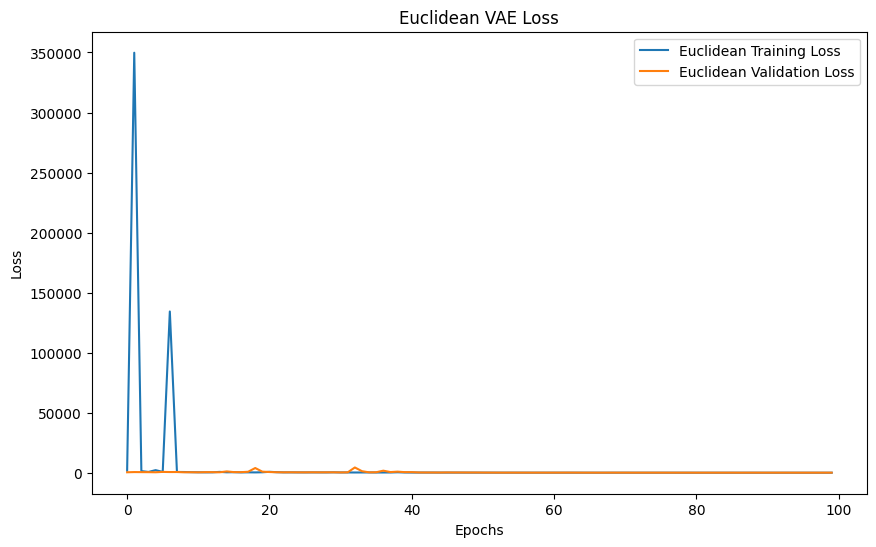

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(euc_history["train_loss"], label="Euclidean Training Loss")
plt.plot(euc_history["val_loss"], label="Euclidean Validation Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()
plt.title("Euclidean VAE Loss")
plt.show()

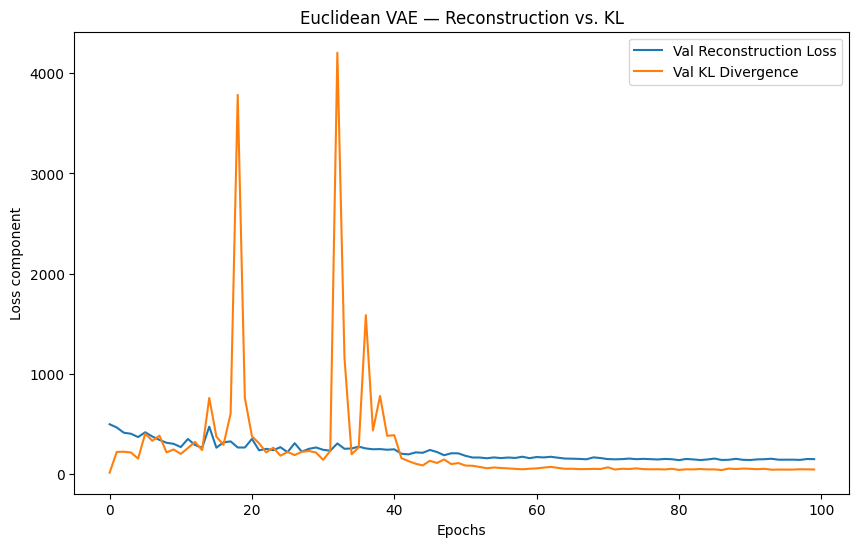

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(euc_history["val_recon"], label="Val Reconstruction Loss")
plt.plot(euc_history["val_kld"], label="Val KL Divergence")
plt.xlabel("Epochs"); plt.ylabel("Loss component"); plt.legend()
plt.title("Euclidean VAE — Reconstruction vs. KL")
plt.show()

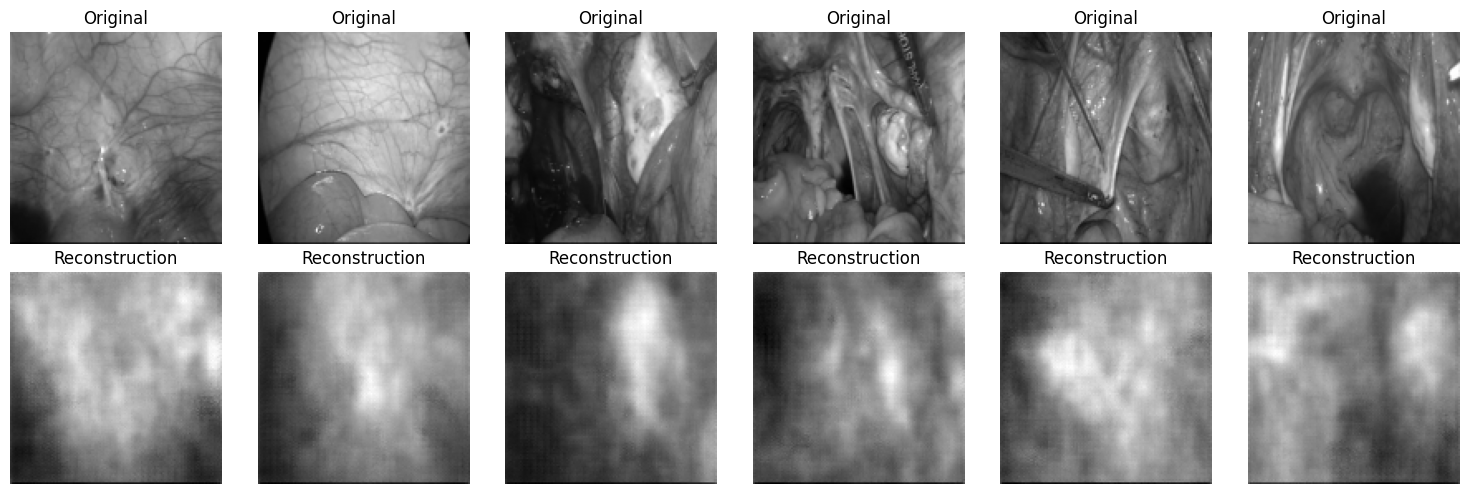

In [19]:
# Visual check: if reconstructions look near-identical to each other
# regardless of the input image, that's posterior collapse, not convergence.
euc_vae.eval()
with torch.no_grad():
    sample_x, _ = next(iter(val_loader))
    sample_x = sample_x[:6].to(DEVICE)
    recon, _, _ = euc_vae(sample_x)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(6):
    axes[0, i].imshow(sample_x[i, 0].cpu(), cmap="gray")
    axes[0, i].set_title("Original"); axes[0, i].axis("off")
    axes[1, i].imshow(recon[i, 0].cpu(), cmap="gray")
    axes[1, i].set_title("Reconstruction"); axes[1, i].axis("off")
plt.tight_layout()
plt.show()

**Hyperbolic Results**

In [20]:
hyp_vae = HyperbolicVAE(IN_CHANNELS, LATENT_DIM, IMG_SIZE, curvature=CURVATURE).to(DEVICE)
hyp_history = train_hyperbolic_vae(hyp_vae, train_loader, val_loader, epochs=EPOCHS)

[Hyperbolic VAE] Epoch 1/100  train=5879.7949  val=607.2832  (recon=599.7602, kld=7.5230)
[Hyperbolic VAE] Epoch 2/100  train=1106.9813  val=626.3188  (recon=522.2328, kld=104.0861)
[Hyperbolic VAE] Epoch 3/100  train=697.5242  val=533.0647  (recon=429.5240, kld=103.5407)
[Hyperbolic VAE] Epoch 4/100  train=579.2068  val=471.1072  (recon=371.7510, kld=99.3561)
[Hyperbolic VAE] Epoch 5/100  train=552.8623  val=480.4460  (recon=321.8470, kld=158.5990)
[Hyperbolic VAE] Epoch 6/100  train=554.4834  val=509.3403  (recon=309.3579, kld=199.9824)
[Hyperbolic VAE] Epoch 7/100  train=477.7842  val=459.8633  (recon=310.8582, kld=149.0051)
[Hyperbolic VAE] Epoch 8/100  train=490.2032  val=659.2024  (recon=339.3479, kld=319.8544)
[Hyperbolic VAE] Epoch 9/100  train=445.6559  val=2367.3762  (recon=357.0861, kld=2010.2900)
[Hyperbolic VAE] Epoch 10/100  train=598.2419  val=489.3122  (recon=306.0232, kld=183.2889)
[Hyperbolic VAE] Epoch 11/100  train=19615.6659  val=548.3654  (recon=262.4753, kld=285.

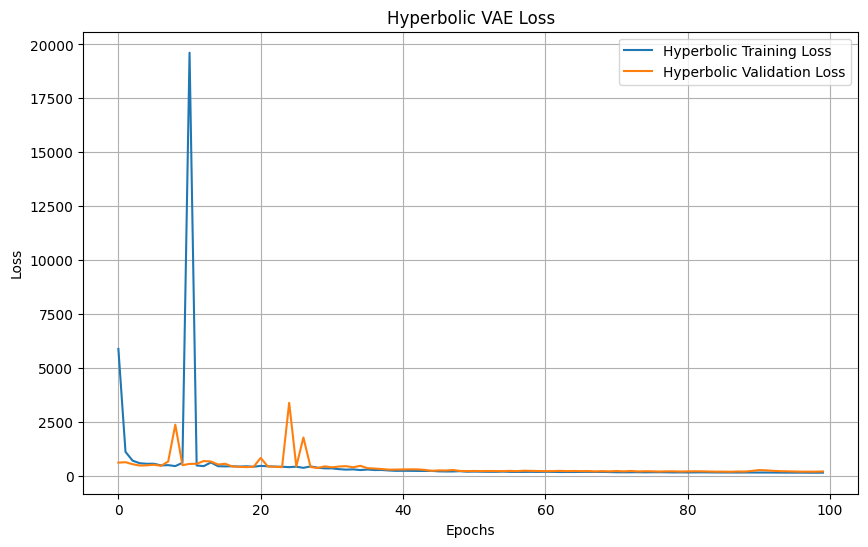

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(hyp_history["train_loss"], label="Hyperbolic Training Loss")
plt.plot(hyp_history["val_loss"], label="Hyperbolic Validation Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
plt.title("Hyperbolic VAE Loss")
plt.show()

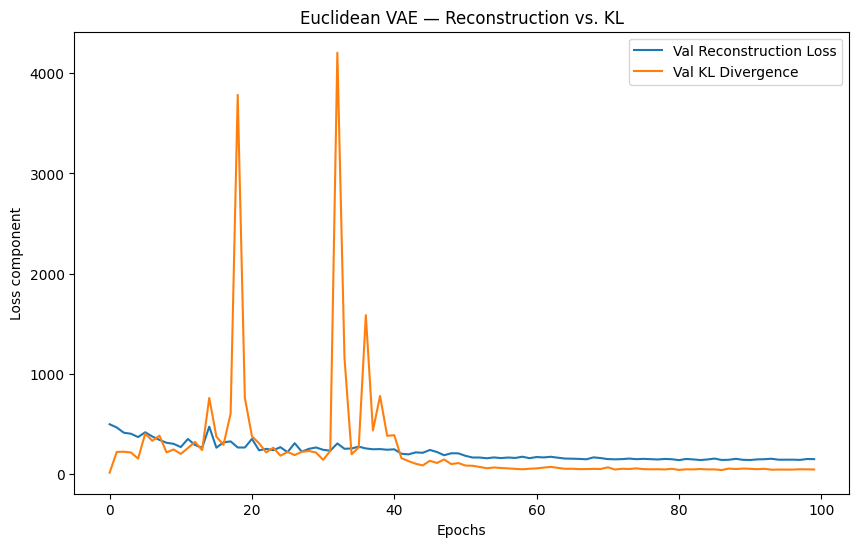

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(euc_history["val_recon"], label="Val Reconstruction Loss")
plt.plot(euc_history["val_kld"], label="Val KL Divergence")
plt.xlabel("Epochs"); plt.ylabel("Loss component"); plt.legend()
plt.title("Euclidean VAE — Reconstruction vs. KL")
plt.show()

In [23]:
euc_vae.eval()
hyp_vae.eval()

def euc_encoder_fn(x):
    mu, _ = euc_vae.encoder(x)
    return mu

def hyp_encoder_fn(x):
    mu, _ = hyp_vae.encoder(x)
    return hyp_vae.ball.expmap0(mu)   # deterministic hyperbolic point from the mean

# **Classifier Results**

In [24]:
print("Training Euclidean-latent CNN classifier...")
euc_clf = LatentCNNClassifier(LATENT_DIM, num_classes).to(DEVICE)
train_classifier(euc_clf, euc_encoder_fn, train_loader, val_loader)
euc_metrics = evaluate_classifier(euc_clf, euc_encoder_fn, test_loader, num_classes)
print(f"Euclidean-latent classifier — accuracy: {euc_metrics['accuracy']:.4f}, "
      f"AUC: {euc_metrics['auc']:.4f}, "
      f"Spearman's rho: {euc_metrics['spearman_corr']:.4f} (p={euc_metrics['spearman_p']:.4f})")

Training Euclidean-latent CNN classifier...
  Epoch 1/50  loss=1.4325  val_acc=0.1250
  Epoch 2/50  loss=1.2948  val_acc=0.2321
  Epoch 3/50  loss=1.1831  val_acc=0.5357
  Epoch 4/50  loss=1.0979  val_acc=0.6964
  Epoch 5/50  loss=1.0266  val_acc=0.6964
  Epoch 6/50  loss=0.9749  val_acc=0.7143
  Epoch 7/50  loss=0.9435  val_acc=0.7143
  Epoch 8/50  loss=0.9168  val_acc=0.6786
  Epoch 9/50  loss=0.8954  val_acc=0.6786
  Epoch 10/50  loss=0.8829  val_acc=0.6786
  Epoch 11/50  loss=0.8747  val_acc=0.6786
  Epoch 12/50  loss=0.8687  val_acc=0.6786
  Epoch 13/50  loss=0.8658  val_acc=0.6786
  Epoch 14/50  loss=0.8598  val_acc=0.6786
  Epoch 15/50  loss=0.8569  val_acc=0.6964
  Epoch 16/50  loss=0.8493  val_acc=0.6786
  Epoch 17/50  loss=0.8513  val_acc=0.6786
  Epoch 18/50  loss=0.8447  val_acc=0.6786
  Epoch 19/50  loss=0.8561  val_acc=0.6786
  Epoch 20/50  loss=0.8511  val_acc=0.6786
  Epoch 21/50  loss=0.8433  val_acc=0.6786
  Epoch 22/50  loss=0.8434  val_acc=0.6786
  Epoch 23/50  loss

In [25]:
print("Training Hyperbolic prototype classifier...")
hyp_clf = HyperbolicPrototypeClassifier(LATENT_DIM, num_classes, curvature=CURVATURE).to(DEVICE)
train_classifier(hyp_clf, hyp_encoder_fn, train_loader, val_loader, manifold_params=True)
hyp_metrics = evaluate_classifier(hyp_clf, hyp_encoder_fn, test_loader, num_classes)
print(f"Hyperbolic-latent classifier — accuracy: {hyp_metrics['accuracy']:.4f}, "
      f"AUC: {hyp_metrics['auc']:.4f}, "
      f"Spearman's rho: {hyp_metrics['spearman_corr']:.4f} (p={hyp_metrics['spearman_p']:.4f})")

Training Hyperbolic prototype classifier...
  Epoch 1/50  loss=1.4048  val_acc=0.2500
  Epoch 2/50  loss=1.4009  val_acc=0.2679
  Epoch 3/50  loss=1.3977  val_acc=0.2500
  Epoch 4/50  loss=1.3946  val_acc=0.2500
  Epoch 5/50  loss=1.3915  val_acc=0.2500
  Epoch 6/50  loss=1.3887  val_acc=0.2321
  Epoch 7/50  loss=1.3856  val_acc=0.2321
  Epoch 8/50  loss=1.3827  val_acc=0.2321
  Epoch 9/50  loss=1.3797  val_acc=0.2500
  Epoch 10/50  loss=1.3767  val_acc=0.2321
  Epoch 11/50  loss=1.3737  val_acc=0.2500
  Epoch 12/50  loss=1.3707  val_acc=0.2500
  Epoch 13/50  loss=1.3678  val_acc=0.2679
  Epoch 14/50  loss=1.3648  val_acc=0.2679
  Epoch 15/50  loss=1.3620  val_acc=0.2679
  Epoch 16/50  loss=1.3593  val_acc=0.3036
  Epoch 17/50  loss=1.3564  val_acc=0.3214
  Epoch 18/50  loss=1.3535  val_acc=0.3214
  Epoch 19/50  loss=1.3506  val_acc=0.3393
  Epoch 20/50  loss=1.3478  val_acc=0.3571
  Epoch 21/50  loss=1.3451  val_acc=0.3750
  Epoch 22/50  loss=1.3423  val_acc=0.3929
  Epoch 23/50  loss

In [26]:
print(f"Summary:\n"
      f"  Euclidean latent space  — accuracy: {euc_metrics['accuracy']:.4f}, "
      f"AUC: {euc_metrics['auc']:.4f}, Spearman's rho: {euc_metrics['spearman_corr']:.4f}\n"
      f"  Hyperbolic latent space — accuracy: {hyp_metrics['accuracy']:.4f}, "
      f"AUC: {hyp_metrics['auc']:.4f}, Spearman's rho: {hyp_metrics['spearman_corr']:.4f}")

Summary:
  Euclidean latent space  — accuracy: 0.6786, AUC: 0.4842, Spearman's rho: -0.1799
  Hyperbolic latent space — accuracy: 0.5179, AUC: 0.5865, Spearman's rho: 0.0123
